<a href="https://colab.research.google.com/github/Thota-Akhilasri/OIBSIP/blob/main/DataScience-Task2-UnemploymentAnalysis/Unemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip archive.zip

Archive:  archive.zip
  inflating: Unemployment in India.csv  
  inflating: Unemployment_Rate_upto_11_2020.csv  


In [ ]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_2604/964314994.py:7: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
# 1. Dataset Overview
print("=" * 40)
print(f"📊 DATASET SHAPE : {df.shape[0]} Rows, {df.shape[1]} Columns")
print("=" * 40)
# 2. Null Values & Data Types Summary
info_df = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Null Values': df.isnull().sum().values
})

print("\n--- Summary Table ---")
print(info_df.to_string(index=False))

📊 DATASET SHAPE : 267 Rows, 9 Columns

--- Summary Table ---
                            Column Name      Data Type  Null Values
                                 Region         object            0
                                   Date datetime64[ns]            0
                              Frequency         object            0
        Estimated Unemployment Rate (%)        float64            0
                     Estimated Employed          int64            0
Estimated Labour Participation Rate (%)        float64            0
                               Region.1         object            0
                              longitude        float64            0
                               latitude        float64            0


/tmp/ipykernel_2604/971174144.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Estimated Unemployment Rate (%)', y='Region', data=top10, palette='coolwarm')


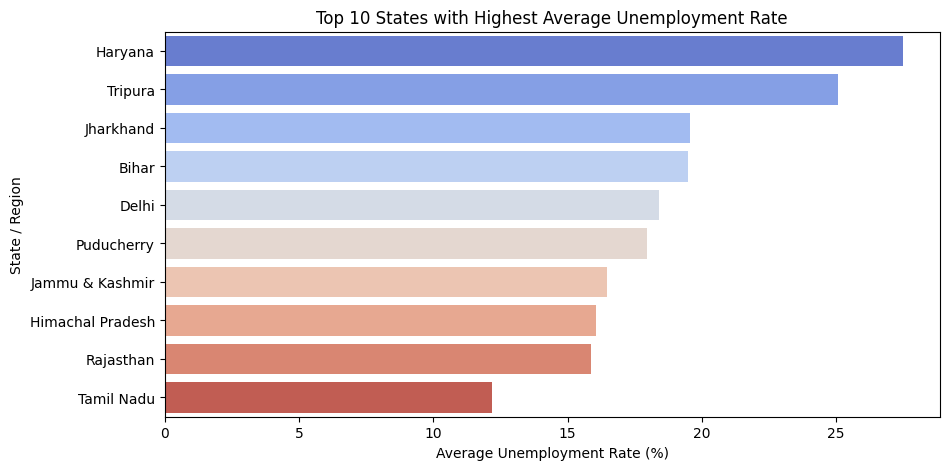

In [ ]:
# Exploratory Data Analysis-The top 10 highest average unemployment rate
plt.figure(figsize=(10, 5))
top10 = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().reset_index().sort_values(by='Estimated Unemployment Rate (%)', ascending=False).head(10)
sns.barplot(x='Estimated Unemployment Rate (%)', y='Region', data=top10, palette='coolwarm')
plt.title('Top 10 States with Highest Average Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('State / Region')
plt.show()


**Observation** : In the above bar chart we can observe the top 10 average unemployment rate that is the Haryana is the top most state/region has more unemployment rate and also the Tamil nadu has less average unemployment rate compare to other states/regions.

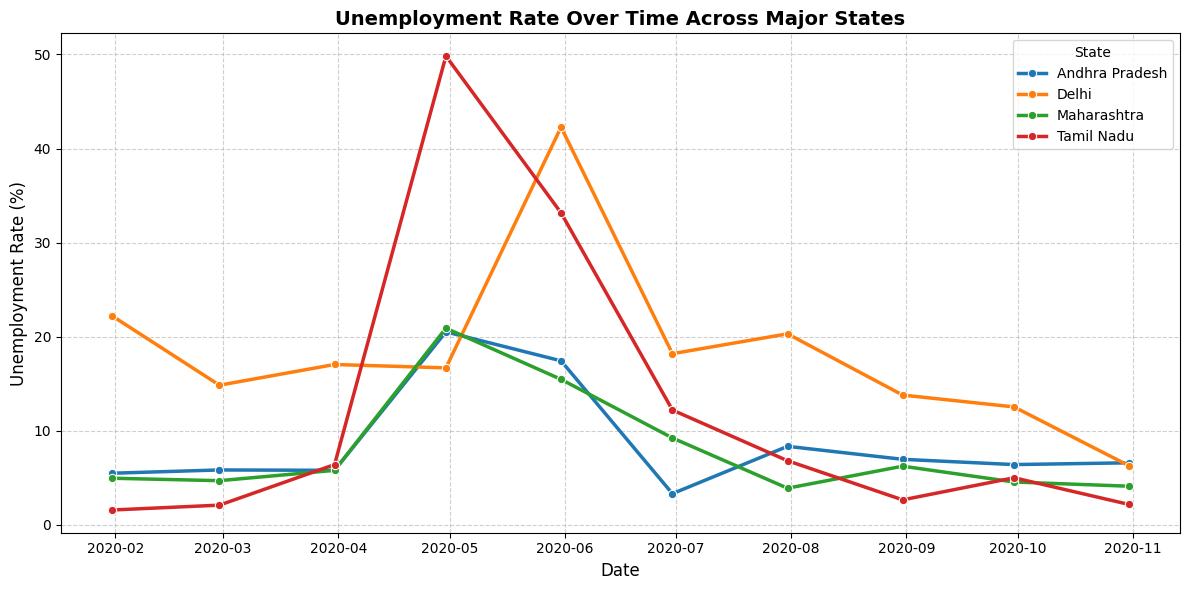

In [ ]:
#Time-Series Line Chart(Analysis) : Unemployment Rate Over Time
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selecting 4 Major States for Comparison
selected_states = df[df['Region'].isin(['Andhra Pradesh', 'Maharashtra', 'Delhi', 'Tamil Nadu'])]

# 2. Time-Series Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=selected_states,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Region',
    marker='o',
    linewidth=2.5
)

plt.title('Unemployment Rate Over Time Across Major States', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='State')
plt.tight_layout()
plt.show()

 **Observation**: We can observe from the above time series chart a sharp spike in unemployment rates is clearly visible between April 2020 and June 2020 across major states due to the strict nation-wide COVID-19 lockdown.

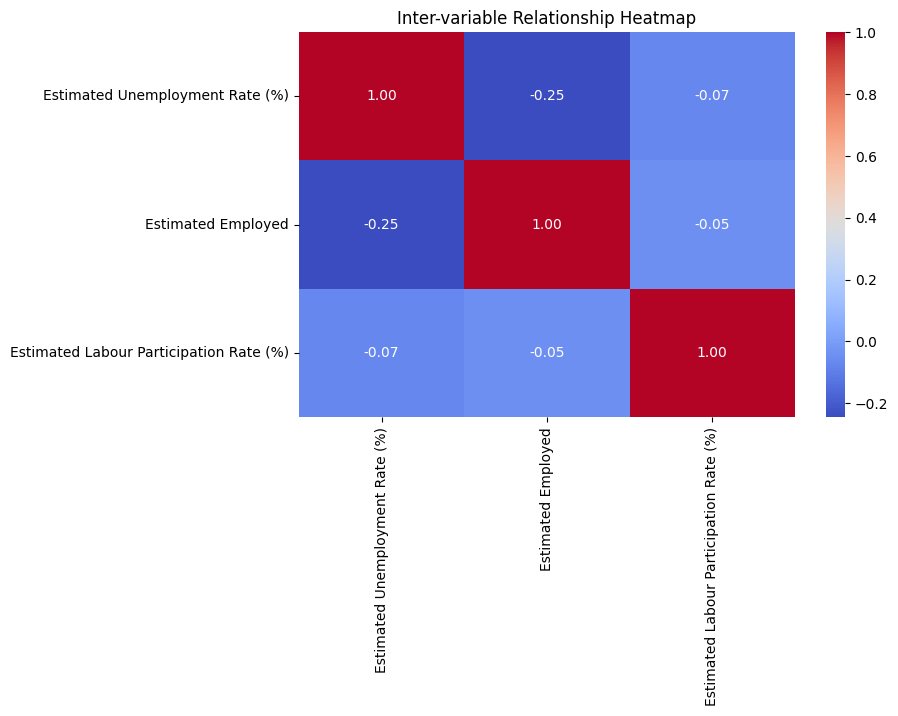

In [ ]:
#Inter-variable Relationship Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Inter-variable Relationship Heatmap')
plt.show()


> **Observation:** There is a negative correlation (-0.25) between the Estimated Unemployment Rate and Estimated Employed population, indicating that as employment drops, unemployment increases.

In [ ]:
#Pre-covid vs Post-covid Analysis
pre_covid = df[df['Date'] < '2020-03-24']['Estimated Unemployment Rate (%)'].mean()
post_covid = df[df['Date'] >= '2020-03-24']['Estimated Unemployment Rate (%)'].mean()
print(f"\n--- Pre vs Post COVID Analysis ---")
print(f"Pre-COVID Average Unemployment Rate: {pre_covid:.2f}%")
print(f"Post-COVID Average Unemployment Rate: {post_covid:.2f}%")


--- Pre vs Post COVID Analysis ---
Pre-COVID Average Unemployment Rate: 9.23%
Post-COVID Average Unemployment Rate: 12.96%


**Observation :** The average unemployment rate is increased significantly from 9.23% to 12.96% that is the unemployment rate is increased after covid.

In [ ]:
# 1. Cleaning region names properly
df['Region'] = df['Region'].str.strip()

# 2. Calculating Top 5 Worst-Affected States
top_states = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
    .sort_values(by='Estimated Unemployment Rate (%)', ascending=False)
    .head(5)
)

print("=" * 55)
print(" TOP 5 WORST AFFECTED STATES (Highest Unemployment) ")
print("=" * 55)

for index, row in top_states.iterrows():
    print(f"📍 {row['Region']:<20} : {row['Estimated Unemployment Rate (%)']:.2f}%")

print("=" * 55)

 TOP 5 WORST AFFECTED STATES (Highest Unemployment) 
📍 Haryana              : 27.48%
📍 Tripura              : 25.05%
📍 Jharkhand            : 19.54%
📍 Bihar                : 19.47%
📍 Delhi                : 18.41%


**Conclusion** : In the above cell we can conclude the Harayana,Tripura,Jharkhand,Bihar and Delhi has more unemployment rate compare to others.